In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Tracer.windfield import WindField
from Tracer.tracer import solver, initial_velocity, fetch_wind_data

In [4]:
# shot input
shot_speed = 76.44384
shot_angle = 10.4	
shot_spin = 2545   	
P0 = [0,0,0]
U_ref = 5
z0 = 0.03
wind_dir = 0
nx = 300
ny = 500
nz = 100
dt = 0.01

# calculating logarithmic
log_wind = WindField(nx=nx, ny=ny, nz=nz, direction=wind_dir, profile='log', z0=z0, U_ref=U_ref)
log_V0 = initial_velocity(speed=shot_speed, angle=shot_angle)
log_W0 = np.array([0, -shot_spin, 0])
log_t, log_p, log_v, log_w = solver(P0, log_V0, log_W0, log_wind, dt=dt)

# calculating uniform
uni_wind = WindField(nx=nx, ny=ny, nz=nz, direction=wind_dir, profile='uniform', z0=z0, U_ref=U_ref)

uni_V0 = initial_velocity(speed=shot_speed, angle=shot_angle)
uni_W0 = np.array([0, -shot_spin, 0])
uni_t, uni_p, uni_v, uni_w = solver(P0, uni_V0, uni_W0, uni_wind, dt=dt)

<function matplotlib.pyplot.show(close=None, block=None)>

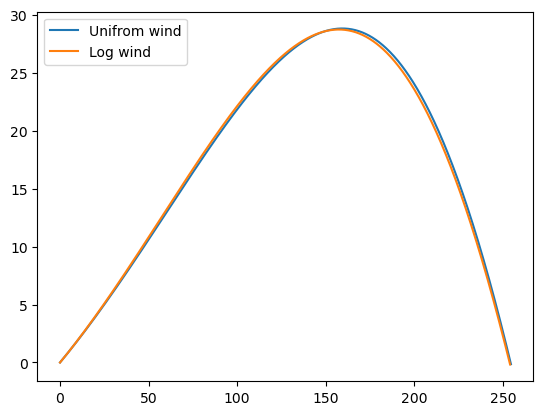

In [5]:
x = np.linspace(0,300)
plt.plot(uni_p[:,0],uni_p[:,2],label='Unifrom wind')
plt.plot(log_p[:,0],log_p[:,2],label='Log wind')
plt.legend()
plt.show

In [12]:
abs(uni_p[-1:,0]-log_p[-1:,0])

array([0.01190913])